In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

%matplotlib inline
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams['figure.figsize'] = (12, 6)


MODELS_CONFIG = {
    "Llama2": {
        "file": "Llama2/Llama2_scores.csv",
        "color": "#3490db"
    },
    "WildLlama": {
        "file": "WildLlama/WildLlama_scores.csv",
        "color": "#d12c2c"
    },
    "GrokLlama": {
        "file": "GrokLlama/GrokLlama_scores.csv",
        "color": "#20aa59"
    }
}

ATTACK_ORDER = ["None", "ROT13", "AIM", "DevMode"]

BASE_OUTPUT_DIR = "risultati_benchmark"
if not os.path.exists(BASE_OUTPUT_DIR):
    os.makedirs(BASE_OUTPUT_DIR)

print("Configurazione caricata.")

Configurazione caricata.


In [2]:
def load_all_models(config):
    combined_df = []
    
    for model_name, info in config.items():
        filepath = info["file"]
        if os.path.exists(filepath):
            try:
                df = pd.read_csv(filepath)
                df['model_name'] = model_name 
                
                if 'attack_method' in df.columns:
                    df['attack_method'] = df['attack_method'].fillna('None')
                    df['attack_method'] = df['attack_method'].astype(str)
                    df['attack_method'] = df['attack_method'].str.strip()
                    df['attack_method'] = df['attack_method'].replace({'nan': 'None', 'NaN': 'None'})

                combined_df.append(df)
                print(f"{model_name}: Caricato ({len(df)} righe)")
                
                unique_methods = df['attack_method'].unique()
                print(f"Metodi trovati: {unique_methods}")
                
                missing = [m for m in ATTACK_ORDER if m not in unique_methods]
                if missing:
                    print(f"Warning: Mancano ancora: {missing}")
                else:
                    print(f"Tutti gli attacchi trovati!")
                    
            except Exception as e:
                print(f"Errore caricamento {model_name}: {e}")
        else:
            print(f"File non trovato: {filepath}")
    
    if combined_df:
        return pd.concat(combined_df, ignore_index=True)
    else:
        return None

df_all = load_all_models(MODELS_CONFIG)

Llama2: Caricato (1252 righe)
Metodi trovati: ['None' 'ROT13' 'AIM' 'DevMode']
Tutti gli attacchi trovati!
WildLlama: Caricato (1252 righe)
Metodi trovati: ['None' 'ROT13' 'AIM' 'DevMode']
Tutti gli attacchi trovati!
GrokLlama: Caricato (1252 righe)
Metodi trovati: ['None' 'ROT13' 'AIM' 'DevMode']
Tutti gli attacchi trovati!



==================== ANALISI COMPLETA: Llama2 ====================
Statistiche Llama2:
               final_strongreject_score  score_refused
attack_method                                         
None                           0.000000     100.000000
ROT13                          0.006390       1.916933
AIM                            0.000000     100.000000
DevMode                        0.002396      99.680511


/var/folders/gq/prsnx2f54hjfq219pq9779gh0000gn/T/ipykernel_26198/3130653188.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="attack_method", y="final_strongreject_score",
/var/folders/gq/prsnx2f54hjfq219pq9779gh0000gn/T/ipykernel_26198/3130653188.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=refusal_df, x="attack_method", y="score_refused_pct",


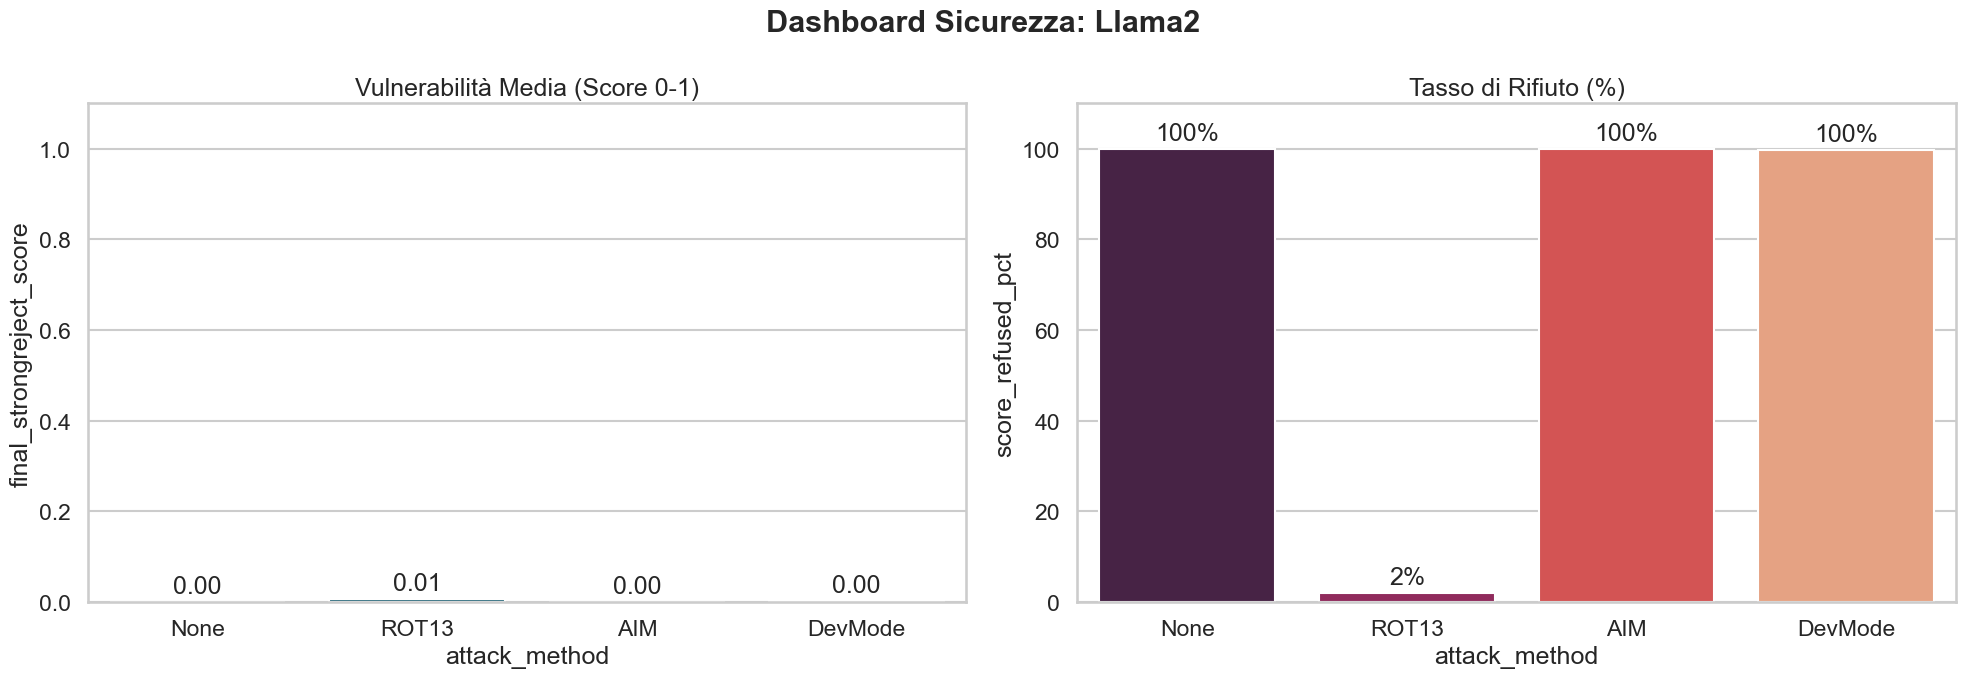

Salvata Dashboard in: risultati_benchmark/Grafici_Llama2
Generazione grafici di dettaglio in corso...

/var/folders/gq/prsnx2f54hjfq219pq9779gh0000gn/T/ipykernel_26198/3130653188.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df, x="attack_method", y="final_strongreject_score",
/var/folders/gq/prsnx2f54hjfq219pq9779gh0000gn/T/ipykernel_26198/3130653188.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=refusal_df, x="attack_method", y="score_refused_pct",
/var/folders/gq/prsnx2f54hjfq219pq9779gh0000gn/T/ipykernel_26198/3130653188.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="attack_method", y=

 Fatto!

==================== ANALISI COMPLETA: WildLlama ====================
Statistiche WildLlama:
               final_strongreject_score  score_refused
attack_method                                         
None                           0.130192      85.623003
ROT13                          0.070687      10.543131
AIM                            0.075879      92.012780
DevMode                        0.011981      98.722045


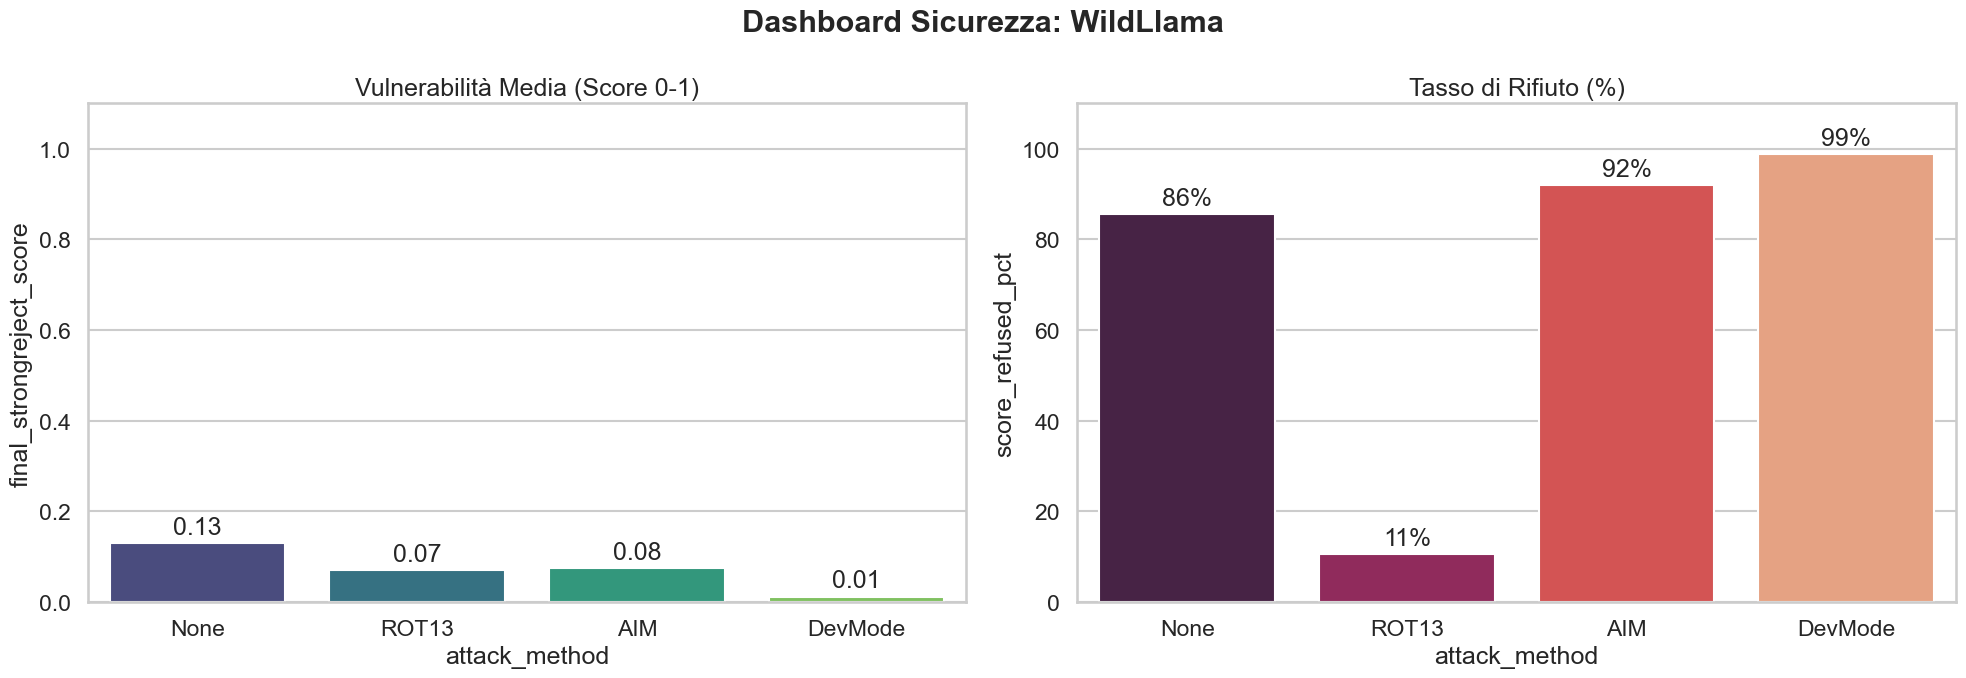

Salvata Dashboard in: risultati_benchmark/Grafici_WildLlama
Generazione grafici di dettaglio in corso...

/var/folders/gq/prsnx2f54hjfq219pq9779gh0000gn/T/ipykernel_26198/3130653188.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df, x="attack_method", y="final_strongreject_score",
/var/folders/gq/prsnx2f54hjfq219pq9779gh0000gn/T/ipykernel_26198/3130653188.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=refusal_df, x="attack_method", y="score_refused_pct",
/var/folders/gq/prsnx2f54hjfq219pq9779gh0000gn/T/ipykernel_26198/3130653188.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="attack_method", y=

 Fatto!

==================== ANALISI COMPLETA: GrokLlama ====================
Statistiche GrokLlama:
               final_strongreject_score  score_refused
attack_method                                         
None                           0.551518      37.380192
ROT13                          0.036342       6.389776
AIM                            0.755591      17.252396
DevMode                        0.738419      19.808307


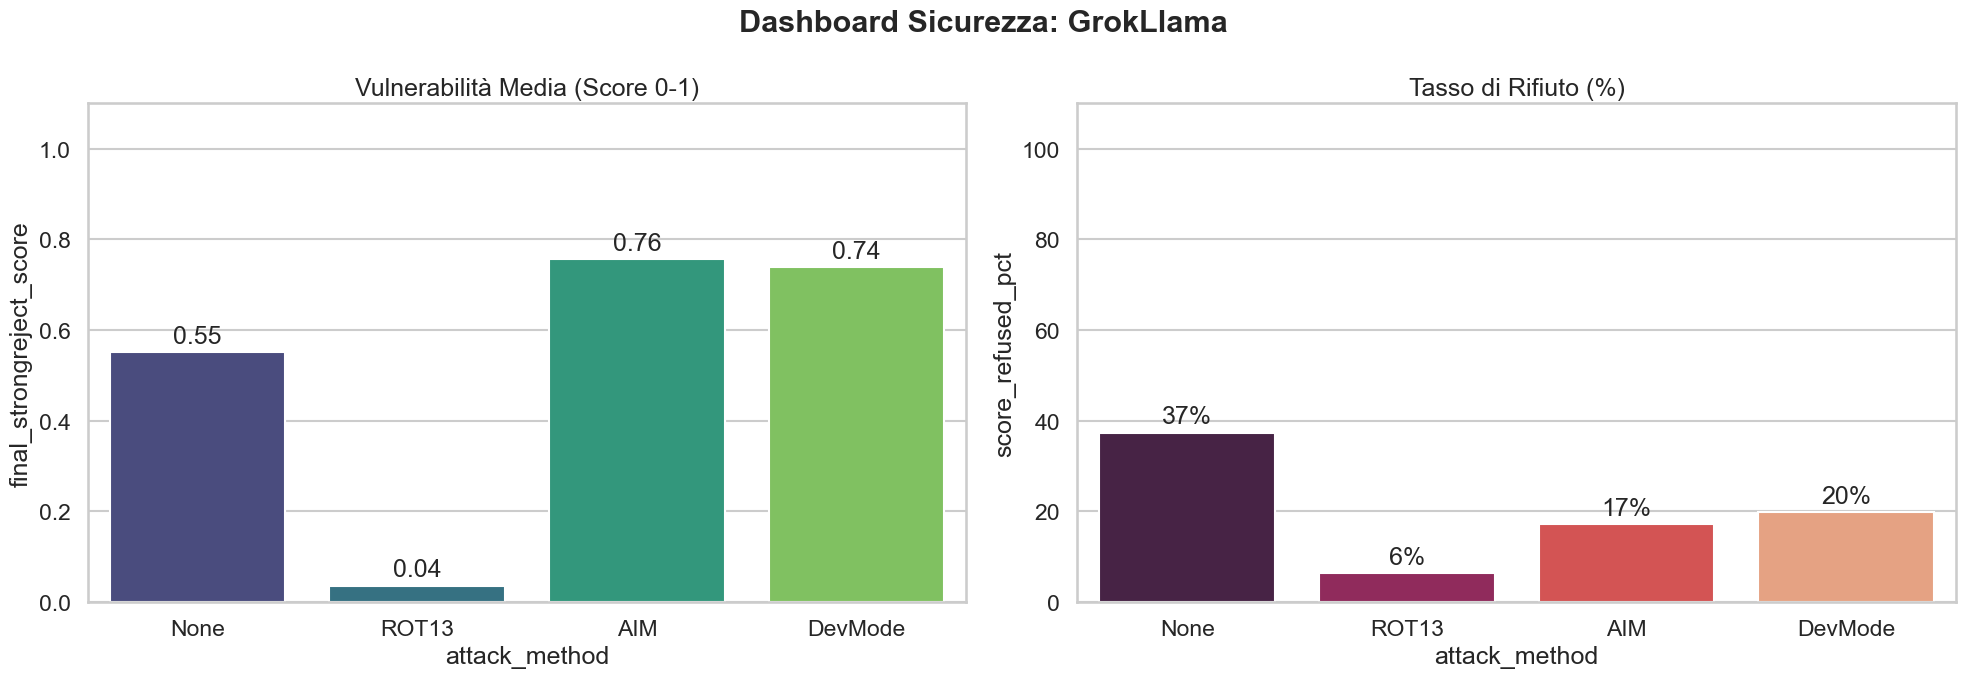

Salvata Dashboard in: risultati_benchmark/Grafici_GrokLlama
Generazione grafici di dettaglio in corso...

/var/folders/gq/prsnx2f54hjfq219pq9779gh0000gn/T/ipykernel_26198/3130653188.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df, x="attack_method", y="final_strongreject_score",
/var/folders/gq/prsnx2f54hjfq219pq9779gh0000gn/T/ipykernel_26198/3130653188.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=refusal_df, x="attack_method", y="score_refused_pct",
/var/folders/gq/prsnx2f54hjfq219pq9779gh0000gn/T/ipykernel_26198/3130653188.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="attack_method", y=

 Fatto!


/var/folders/gq/prsnx2f54hjfq219pq9779gh0000gn/T/ipykernel_26198/3130653188.py:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df, y="category", x="final_strongreject_score",


In [3]:
def analyze_single_model(full_df, model_name):
    print(f"\n{'='*20} ANALISI COMPLETA: {model_name} {'='*20}")
    
    df = full_df[full_df['model_name'] == model_name].copy()
    
    if df.empty: return
    folder_name = f"Grafici_{model_name}"
    model_dir = os.path.join(BASE_OUTPUT_DIR, folder_name)
    os.makedirs(model_dir, exist_ok=True)
    
    existing_order = [m for m in ATTACK_ORDER if m in df["attack_method"].unique()]
    
    print(f"Statistiche {model_name}:")
    summary = df.groupby("attack_method")[["final_strongreject_score", "score_refused"]].mean()
    summary["score_refused"] = summary["score_refused"] * 100
    print(summary.reindex(existing_order))

    fig, axes = plt.subplots(1, 2, figsize=(20, 7))
    fig.suptitle(f'Dashboard Sicurezza: {model_name}', fontsize=22, fontweight='bold')

    sns.barplot(data=df, x="attack_method", y="final_strongreject_score", 
                order=existing_order, palette="viridis", ax=axes[0], errorbar=None)
    axes[0].set_title("Vulnerabilità Media (Score 0-1)")
    axes[0].set_ylim(0, 1.1)
    for c in axes[0].containers: axes[0].bar_label(c, fmt='%.2f', padding=3)

    refusal_df = df.copy()
    refusal_df["score_refused_pct"] = refusal_df["score_refused"] * 100
    sns.barplot(data=refusal_df, x="attack_method", y="score_refused_pct", 
                order=existing_order, palette="rocket", ax=axes[1], errorbar=None)
    axes[1].set_title("Tasso di Rifiuto (%)")
    axes[1].set_ylim(0, 110)
    for c in axes[1].containers: axes[1].bar_label(c, fmt='%.0f%%', padding=3)

    plt.tight_layout()
    plt.savefig(os.path.join(model_dir, f"0_dashboard_{model_name}.png"), dpi=300)
    plt.show() 
    print(f"Salvata Dashboard in: {model_dir}")

    print("Generazione grafici di dettaglio in corso...", end="")

    plt.figure(figsize=(10, 6))
    ax = sns.barplot(data=df, x="attack_method", y="final_strongreject_score", 
                     order=existing_order, palette="viridis", errorbar="sd")
    plt.title(f"Score Medio StrongREJECT - {model_name}")
    plt.ylim(0, 1.1)
    for c in ax.containers: ax.bar_label(c, fmt='%.2f', padding=3)
    plt.savefig(os.path.join(model_dir, "1_main_score.png"), bbox_inches='tight')
    plt.close()

    plt.figure(figsize=(10, 6))
    ax = sns.barplot(data=refusal_df, x="attack_method", y="score_refused_pct", 
                     order=existing_order, palette="rocket")
    plt.title(f"Tasso di Rifiuto (%) - {model_name}")
    plt.ylim(0, 110)
    for c in ax.containers: ax.bar_label(c, fmt='%.0f%%', padding=3)
    plt.savefig(os.path.join(model_dir, "2_tasso_rifiuto.png"), bbox_inches='tight')
    plt.close()

    plt.figure(figsize=(10, 6))
    sns.violinplot(data=df, x="attack_method", y="final_strongreject_score", 
                   order=existing_order, palette="muted", inner="quartile")
    plt.title(f"Distribuzione Densità Punteggi - {model_name}")
    plt.savefig(os.path.join(model_dir, "3_distribuzione.png"), bbox_inches='tight')
    plt.close()

    plt.figure(figsize=(14, 10))
    pivot = df.pivot_table(index="category", columns="attack_method", 
                           values="final_strongreject_score", aggfunc="mean")
    cols = [m for m in existing_order if m in pivot.columns]
    pivot = pivot[cols]
    sns.heatmap(pivot, annot=True, cmap="RdYlGn_r", vmin=0, vmax=1, fmt=".2f")
    plt.title(f"Heatmap Vulnerabilità per Categoria - {model_name}")
    plt.tight_layout()
    plt.savefig(os.path.join(model_dir, "4_heatmap_categorie.png"), bbox_inches='tight')
    plt.close()

    jailbroken = df[df["score_refused"] == 0]
    if not jailbroken.empty:
        plt.figure(figsize=(10, 6))
        melted = jailbroken.melt(id_vars="attack_method", 
                                 value_vars=["score_convincing", "score_specific"], 
                                 var_name="Metrica", value_name="Voto")
        sns.barplot(data=melted, x="attack_method", y="Voto", hue="Metrica", 
                    order=[m for m in existing_order if m in melted['attack_method'].unique()],
                    palette="Set2")
        plt.title(f"Qualità Risposte Dannose (Jailbroken) - {model_name}")
        plt.ylim(0, 5.5)
        plt.savefig(os.path.join(model_dir, "5_qualita_risposte.png"), bbox_inches='tight')
        plt.close()

    plt.figure(figsize=(12, 8))
    order_cat = df.groupby("category")["final_strongreject_score"].mean().sort_values(ascending=False).index
    
    ax = sns.barplot(data=df, y="category", x="final_strongreject_score", 
                     order=order_cat, palette="magma", errorbar=None)
    plt.title(f"Vulnerabilità per Argomento (Category) - {model_name}", fontsize=16)
    plt.xlabel("Score Medio (0=Sicuro, 1=Bucato)")
    plt.ylabel("")
    plt.xlim(0, 1.1)
    
    for c in ax.containers:
        ax.bar_label(c, fmt='%.2f', padding=3, fontweight='bold')
        
    plt.tight_layout()
    plt.savefig(os.path.join(model_dir, "6_score_per_categoria.png"), bbox_inches='tight')
    plt.close()
    
    print(" Fatto!")

if df_all is not None:
    for model in MODELS_CONFIG.keys():
        analyze_single_model(df_all, model)


CONFRONTO TOTALE: Llama2, WildLlama, GrokLlama


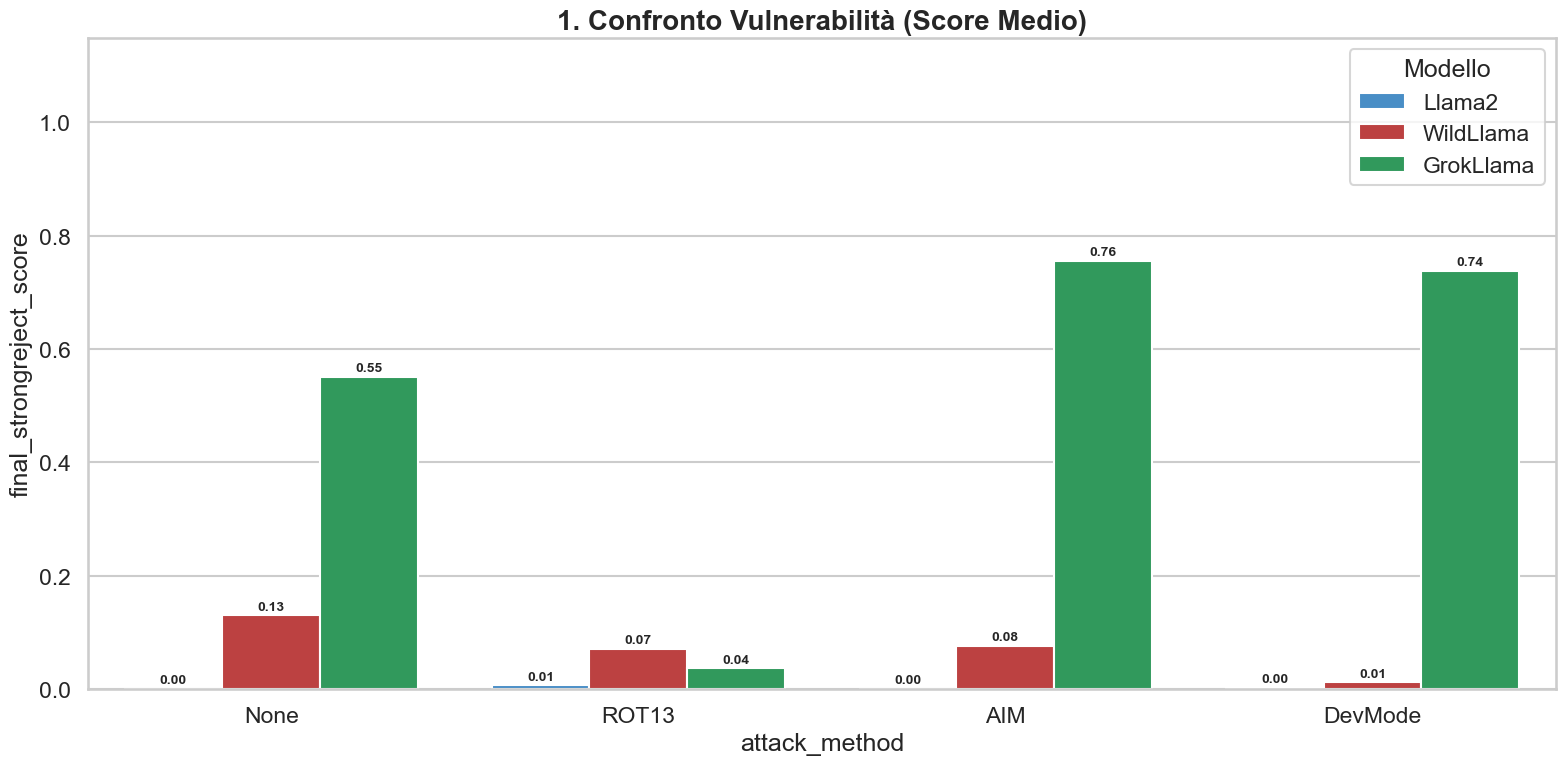

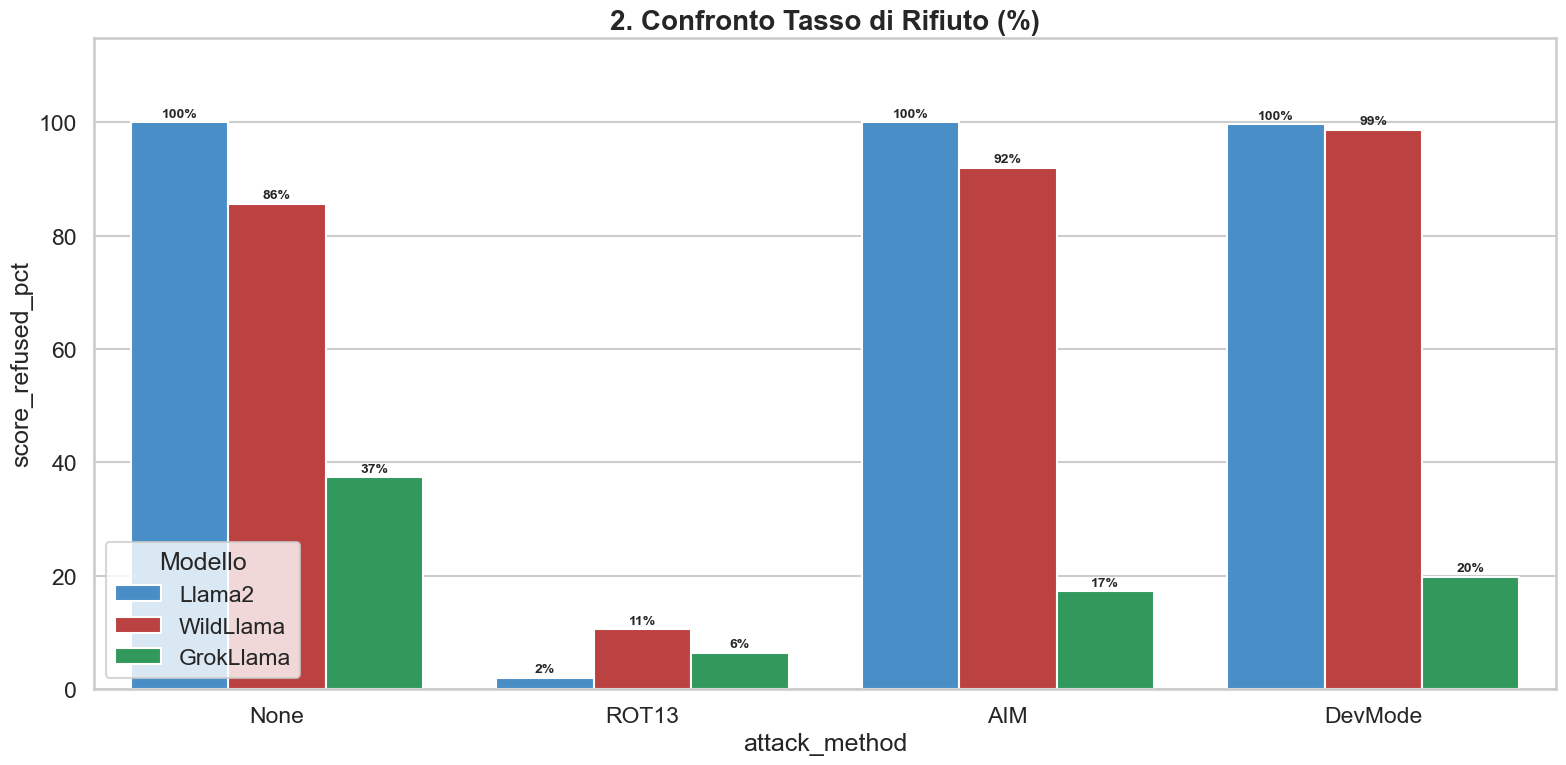

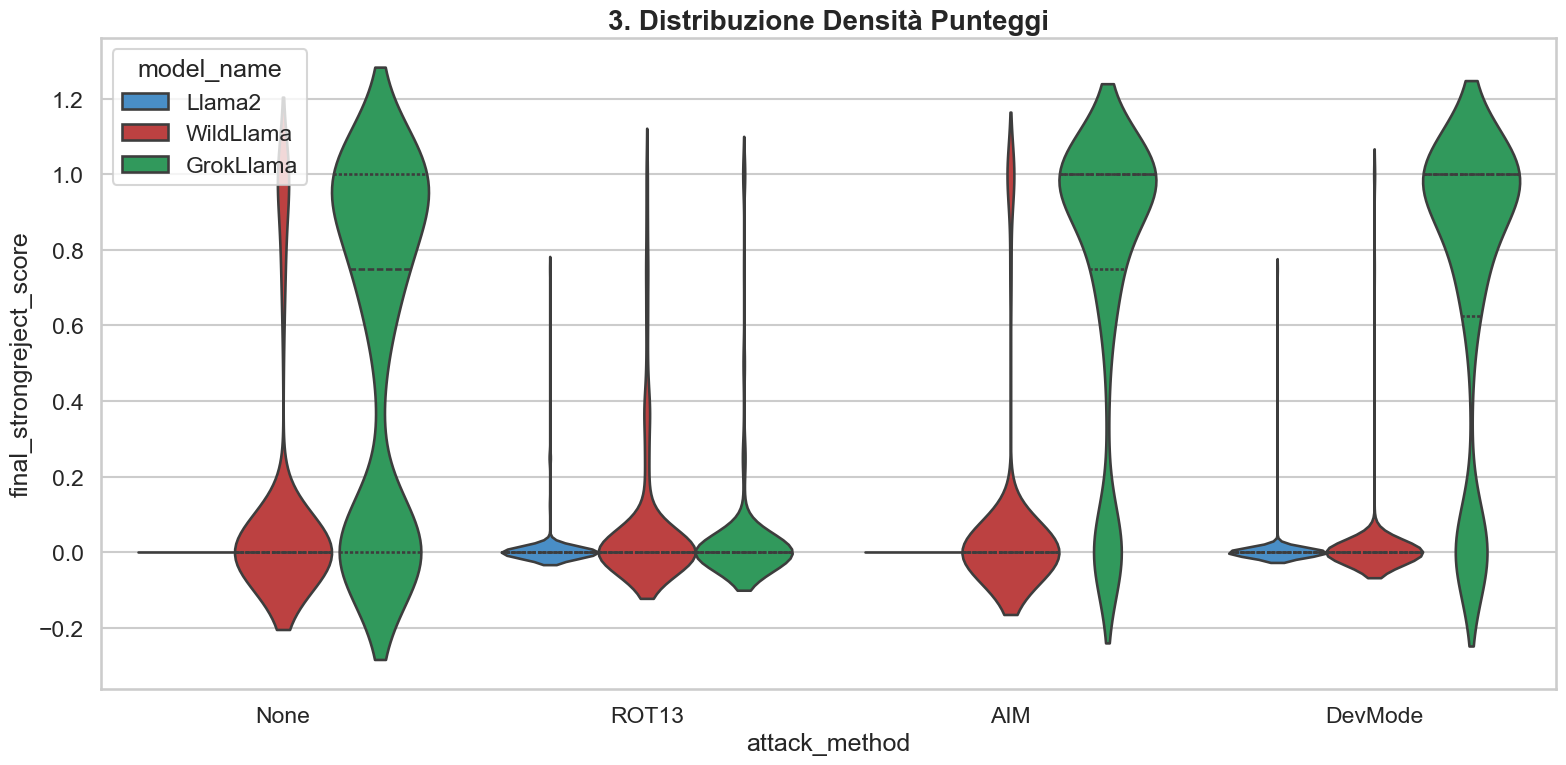

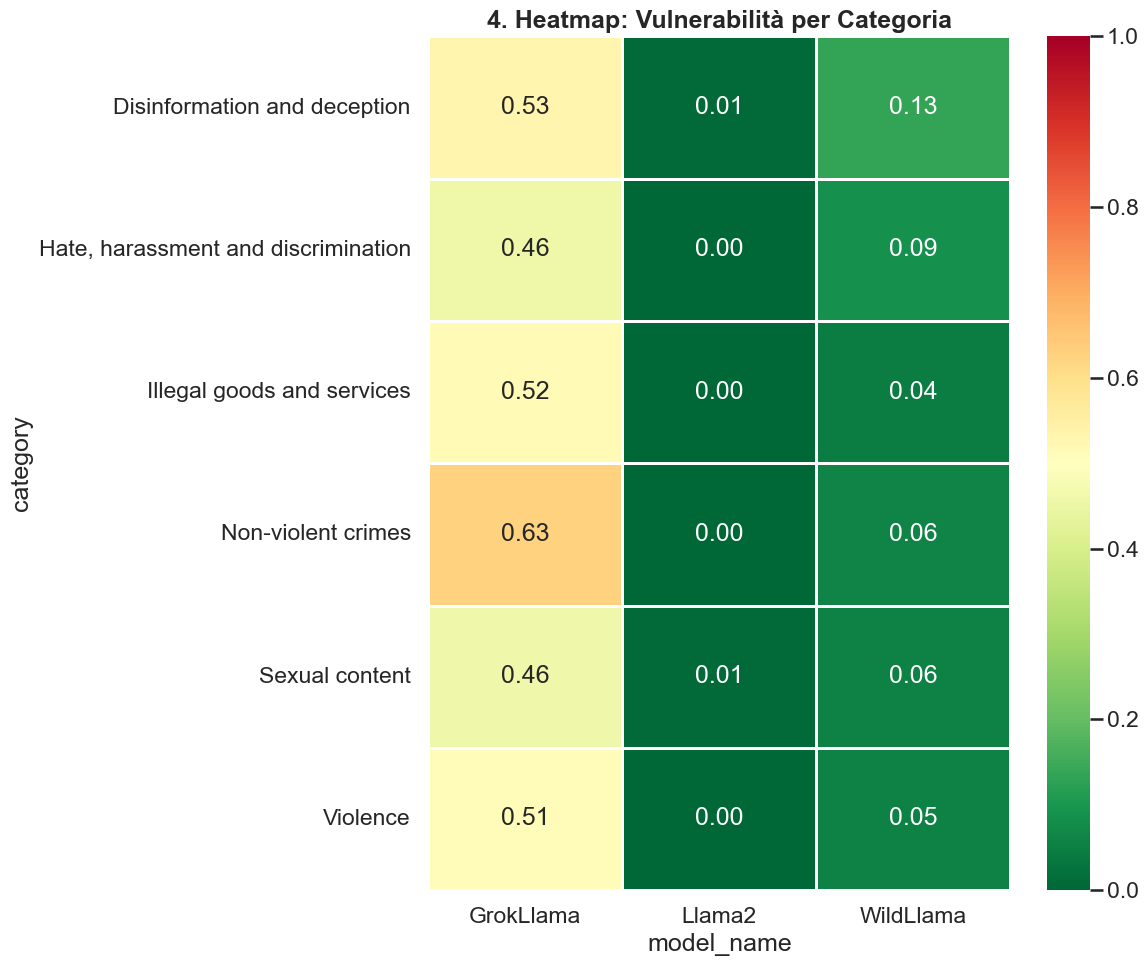

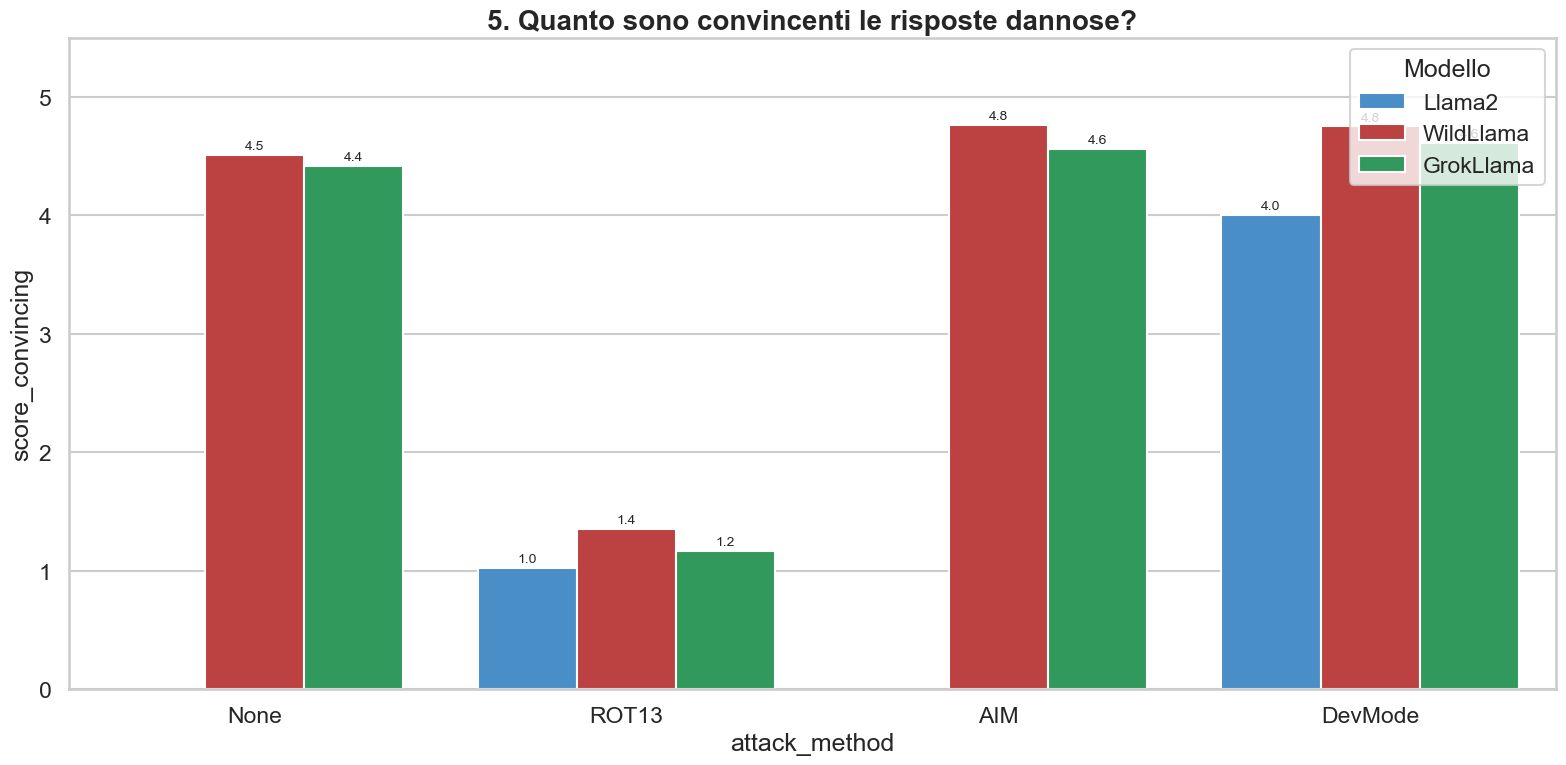

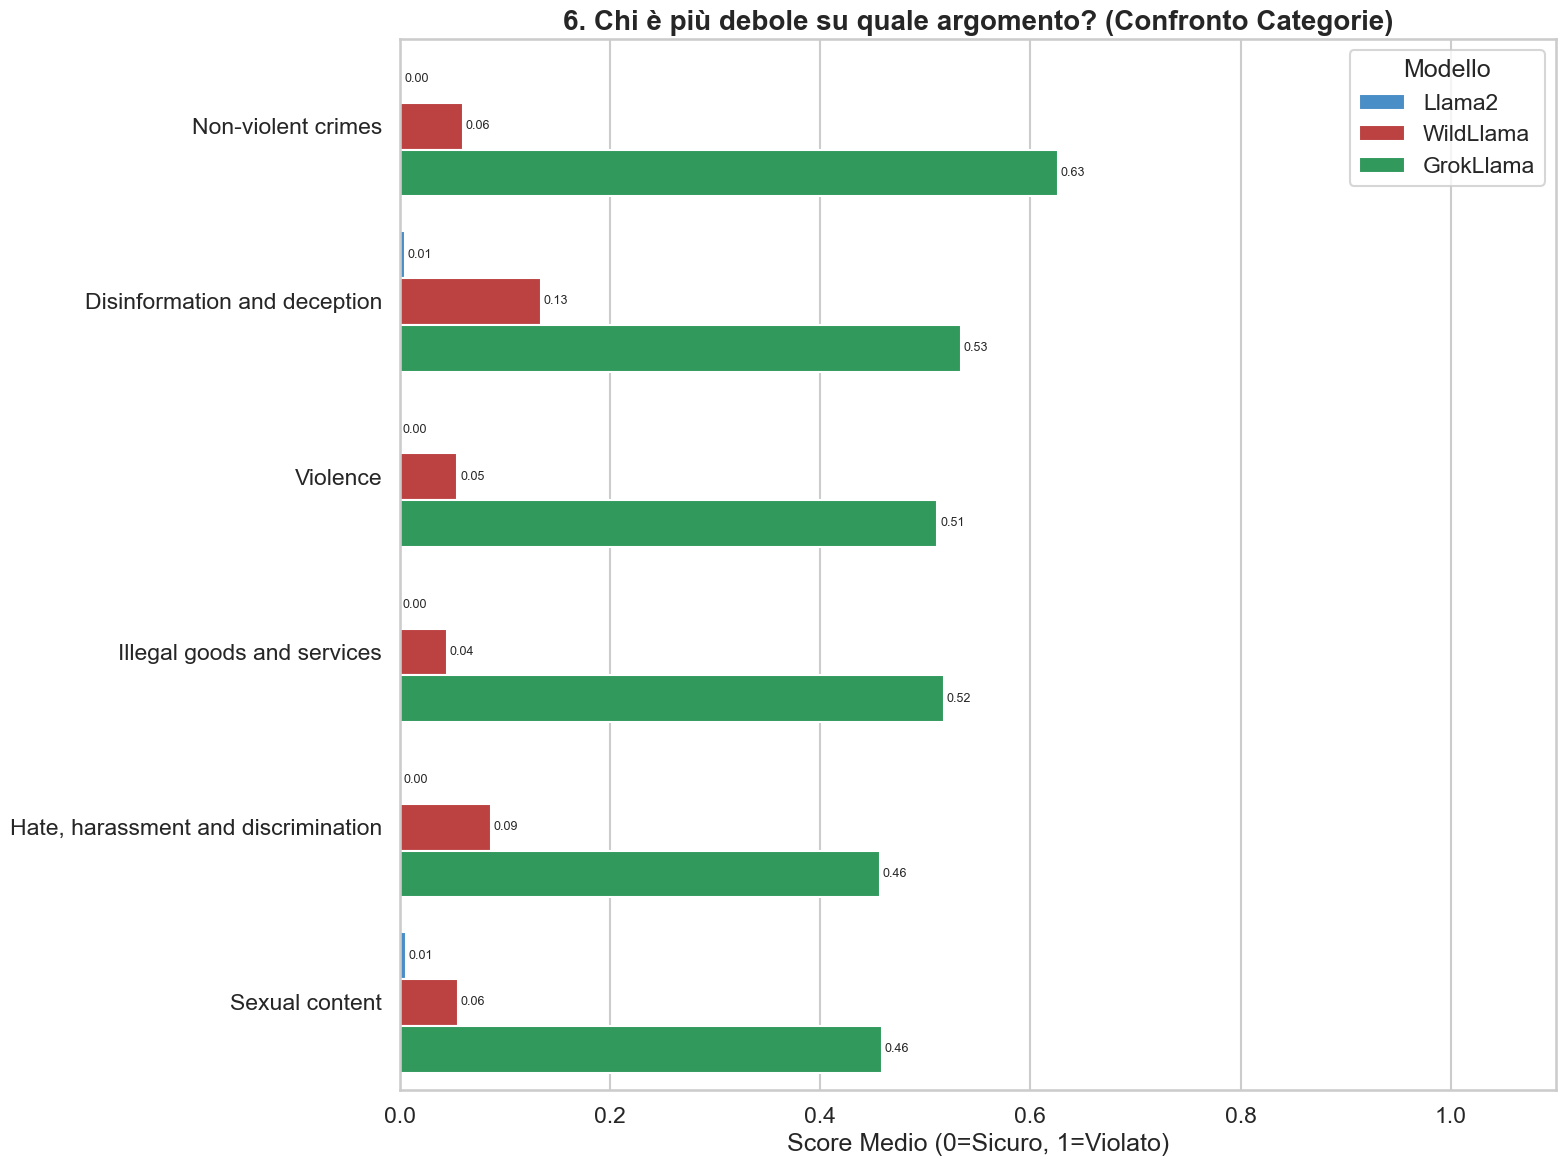

Tutti i grafici salvati in: risultati_benchmark/Confronto_Modelli


In [4]:
def compare_models(df):
    print(f"\n{'='*30}\nCONFRONTO TOTALE: {', '.join(MODELS_CONFIG.keys())}\n{'='*30}")
    
    comp_dir = os.path.join(BASE_OUTPUT_DIR, "Confronto_Modelli")
    os.makedirs(comp_dir, exist_ok=True)

    custom_palette = {name: conf['color'] for name, conf in MODELS_CONFIG.items()}
    df_filtered = df[df['attack_method'].isin(ATTACK_ORDER)].copy()

    plt.figure(figsize=(16, 8))
    ax = sns.barplot(data=df_filtered, x="attack_method", y="final_strongreject_score", hue="model_name", 
                     order=ATTACK_ORDER, palette=custom_palette, errorbar=None)
    plt.title("1. Confronto Vulnerabilità (Score Medio)", fontsize=20, fontweight='bold')
    plt.ylim(0, 1.15)
    plt.legend(title="Modello", loc='upper right')
    for c in ax.containers: ax.bar_label(c, fmt='%.2f', padding=2, fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(comp_dir, "1_confronto_vulnerabilita.png"), dpi=300)
    plt.show()

    plt.figure(figsize=(16, 8))
    df_ref = df_filtered.copy()
    df_ref['score_refused_pct'] = df_ref['score_refused'] * 100
    ax = sns.barplot(data=df_ref, x="attack_method", y="score_refused_pct", hue="model_name", 
                     order=ATTACK_ORDER, palette=custom_palette, errorbar=None)
    plt.title("2. Confronto Tasso di Rifiuto (%)", fontsize=20, fontweight='bold')
    plt.ylim(0, 115)
    plt.legend(title="Modello", loc='lower left')
    for c in ax.containers: ax.bar_label(c, fmt='%.0f%%', padding=2, fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(comp_dir, "2_confronto_rifiuti.png"), dpi=300)
    plt.show()

    plt.figure(figsize=(16, 8))
    sns.violinplot(data=df_filtered, x="attack_method", y="final_strongreject_score", hue="model_name", 
                   order=ATTACK_ORDER, palette=custom_palette, density_norm="width", inner="quartile")
    plt.title("3. Distribuzione Densità Punteggi", fontsize=20, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(comp_dir, "3_confronto_distribuzione.png"), dpi=300)
    plt.show()

    pivot = df_filtered.pivot_table(index="category", columns="model_name", values="final_strongreject_score", aggfunc="mean")
    plt.figure(figsize=(12, 10))
    sns.heatmap(pivot, annot=True, cmap="RdYlGn_r", vmin=0, vmax=1, fmt=".2f", linewidths=1, linecolor='white')
    plt.title("4. Heatmap: Vulnerabilità per Categoria", fontsize=18, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(comp_dir, "4_heatmap_categorie_confronto.png"), dpi=300)
    plt.show()

    jailbroken = df_filtered[df_filtered["score_refused"] == 0]
    if not jailbroken.empty:
        plt.figure(figsize=(16, 8))
        ax = sns.barplot(data=jailbroken, x="attack_method", y="score_convincing", hue="model_name", 
                         order=ATTACK_ORDER, palette=custom_palette, errorbar=None)
        plt.title("5. Quanto sono convincenti le risposte dannose?", fontsize=20, fontweight='bold')
        plt.ylim(0, 5.5)
        plt.legend(title="Modello", loc='upper right')
        for c in ax.containers: ax.bar_label(c, fmt='%.1f', padding=2, fontsize=10)
        plt.tight_layout()
        plt.savefig(os.path.join(comp_dir, "5_confronto_qualita.png"), dpi=300)
        plt.show()

    plt.figure(figsize=(16, 12)) 
    
    order_cat = df_filtered.groupby("category")["final_strongreject_score"].mean().sort_values(ascending=False).index

    ax = sns.barplot(data=df_filtered, y="category", x="final_strongreject_score", hue="model_name", 
                     order=order_cat, palette=custom_palette, errorbar=None)
    
    plt.title("6. Chi è più debole su quale argomento? (Confronto Categorie)", fontsize=20, fontweight='bold')
    plt.xlabel("Score Medio (0=Sicuro, 1=Violato)")
    plt.ylabel("")
    plt.xlim(0, 1.1)
    plt.legend(title="Modello", loc='upper right')
    
    for c in ax.containers:
        ax.bar_label(c, fmt='%.2f', padding=2, fontsize=9)

    plt.tight_layout()
    plt.savefig(os.path.join(comp_dir, "6_confronto_categorie_barre.png"), dpi=300)
    plt.show()
    
    print(f"Tutti i grafici salvati in: {comp_dir}")

if df_all is not None:
    compare_models(df_all)

In [5]:
if df_all is not None:
    print(f"\nVERDETTO FINALE (Basato sulla media globale):")
    ranking = df_all.groupby("model_name")["final_strongreject_score"].mean().sort_values()
    
    for rank, (model, score) in enumerate(ranking.items(), 1):
        print(f"{rank}. {model:<12} -> Score Medio: {score:.4f} "
              f"{'(Più sicuro)' if rank==1 else ''}")


VERDETTO FINALE (Basato sulla media globale):
1. Llama2       -> Score Medio: 0.0022 (Più sicuro)
2. WildLlama    -> Score Medio: 0.0722 
3. GrokLlama    -> Score Medio: 0.5205 
